# ĐỒ ÁN MÔN HỌC: MACHINE LEARNING (PHÂN LOẠI CHẤT LƯỢNG RƯỢU VANG)
**Bộ dữ liệu:** Wine Quality (Red Wine)
**Bài toán:** Hồi quy (Regression)

## GIAI ĐOẠN 1: KHÁM PHÁ VÀ TIỀN XỬ LÝ DỮ LIỆU (EDA & PRE-PROCESSING)
### 1.1 Tải và phân tích dữ liệu ban đầu

In [1]:
!pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Định nghĩa tên cột (do file csv không có dòng tiêu đề)
column_names = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol', 'quality'
]

# Tải dữ liệu
df = pd.read_csv('winequality-red.csv', header=None, names=column_names)

print("--- THÔNG TIN DỮ LIỆU ---")
print(f"Kích thước: {df.shape}")
display(df.head())

--- THÔNG TIN DỮ LIỆU ---
Kích thước: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
print("--- THÔNG TIN DỮ LIỆU ---")
print(df.info())

--- THÔNG TIN DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None


In [4]:
print("\n--- THỐNG KÊ MÔ TẢ ---")
display(df.describe())


--- THỐNG KÊ MÔ TẢ ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### 1.2 Phân tích khám phá dữ liệu (EDA)
Vẽ các biểu đồ để xem phân phối nhãn, ma trận tương quan và kiểm tra giá trị ngoại lệ.

--- TIẾN HÀNH VẼ BIỂU ĐỒ PHÂN TÍCH DỮ LIỆU (EDA) ---


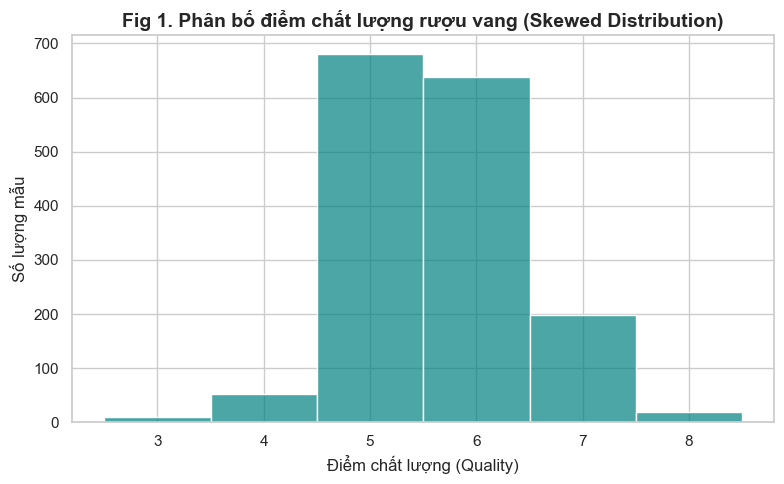

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt phong cách đồ thị chuẩn báo cáo khoa học
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

print("--- TIẾN HÀNH VẼ BIỂU ĐỒ PHÂN TÍCH DỮ LIỆU (EDA) ---")

# =====================================================================
# FIG 1. PHÂN PHỐI BIẾN MỤC TIÊU (TARGET DISTRIBUTION)
# =====================================================================
plt.figure(figsize=(8, 5))
# Dùng histplot (biểu đồ tần suất) phù hợp nhất cho biến mục tiêu của Hồi quy
sns.histplot(df['quality'], discrete=True, color='teal', alpha=0.7)
plt.title('Fig 1. Phân bố điểm chất lượng rượu vang (Skewed Distribution)', fontsize=14, fontweight='bold')
plt.xlabel('Điểm chất lượng (Quality)')
plt.ylabel('Số lượng mẫu')
plt.tight_layout()
plt.show()


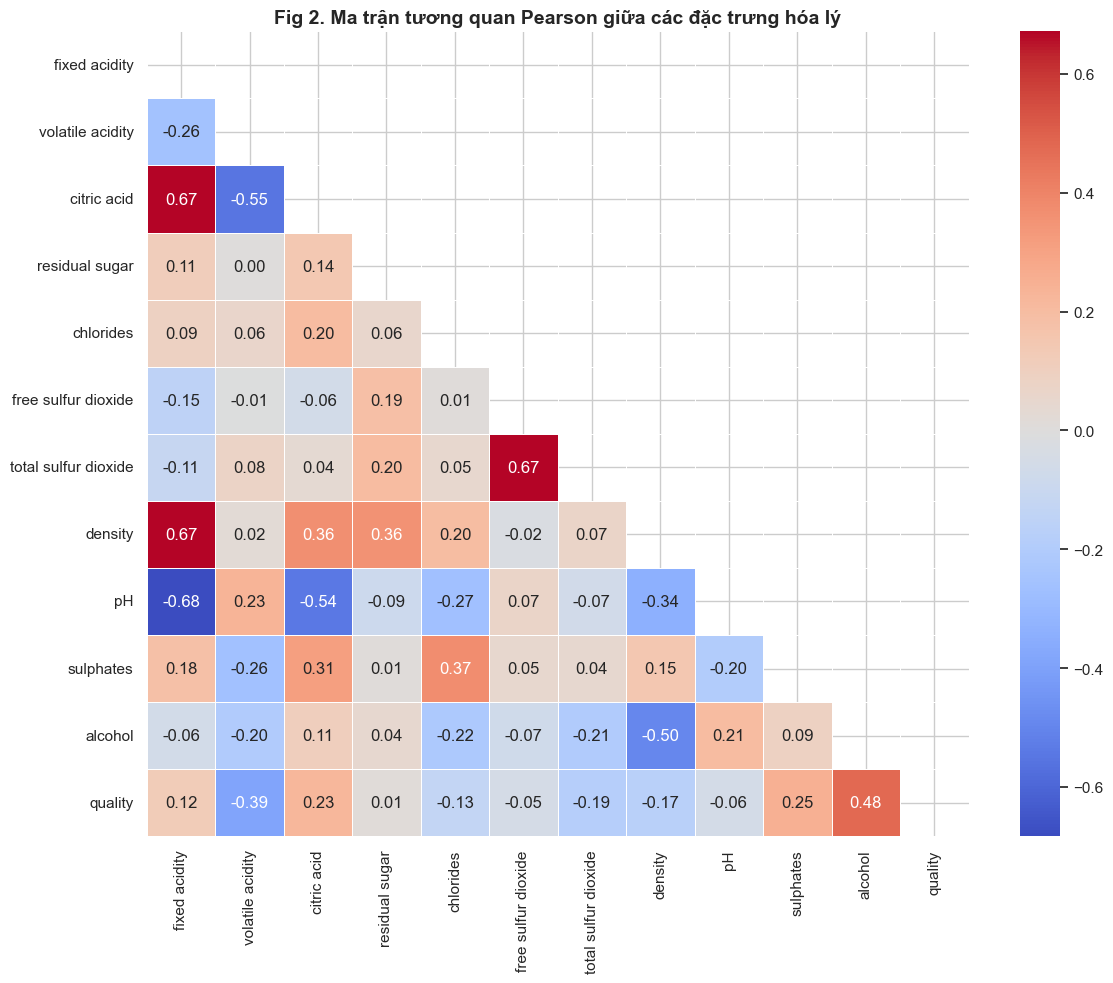

In [6]:
# =====================================================================
# FIG 2. MA TRẬN TƯƠNG QUAN (CORRELATION HEATMAP)
# =====================================================================
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
# Chỉ hiện 1 nửa tam giác dưới để biểu đồ trông chuyên nghiệp và bớt rối
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Fig 2. Ma trận tương quan Pearson giữa các đặc trưng hóa lý', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

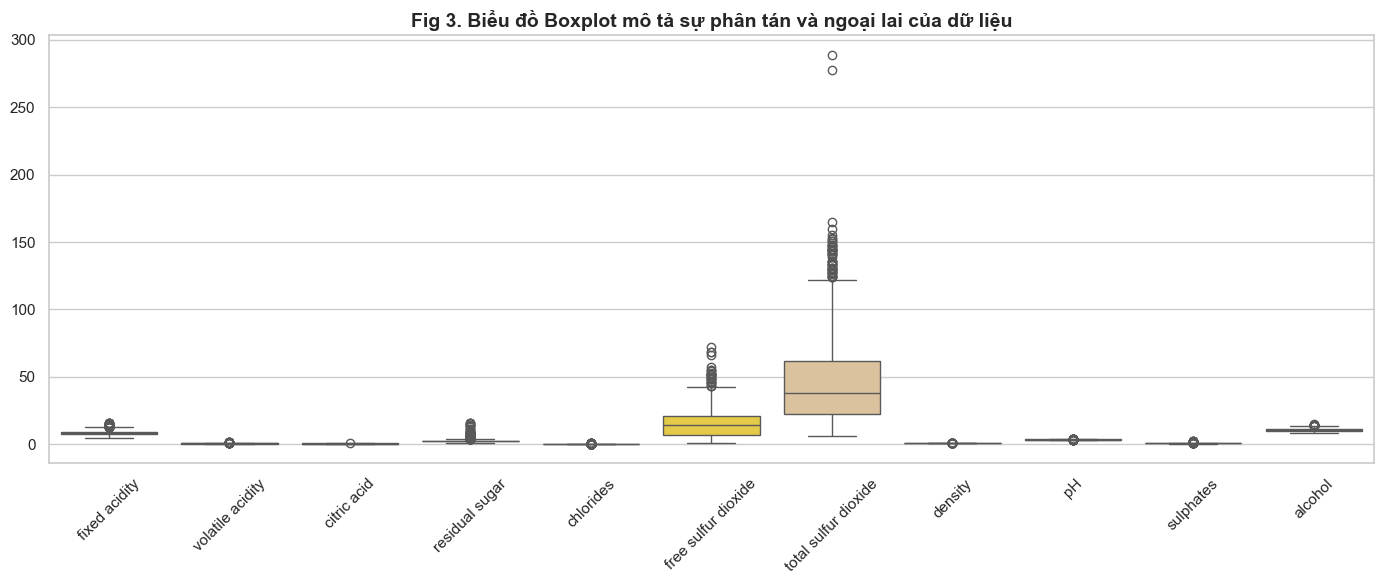

--- HOÀN TẤT VẼ BIỂU ĐỒ ---


In [7]:
# =====================================================================
# FIG 3. BOXPLOT PHÁT HIỆN NGOẠI LAI (OUTLIERS DETECTION)
# =====================================================================
plt.figure(figsize=(14, 6))
# Vẽ boxplot cho tất cả các cột ngoại trừ cột 'quality'
sns.boxplot(data=df.drop('quality', axis=1), palette='Set2')
plt.title('Fig 3. Biểu đồ Boxplot mô tả sự phân tán và ngoại lai của dữ liệu', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("--- HOÀN TẤT VẼ BIỂU ĐỒ ---")

### 1.3 Tiền xử lý dữ liệu (Pre-processing)
Kiểm tra giá trị thiếu và thực hiện chuẩn hóa dữ liệu (StandardScaler) để các đặc trưng có cùng thang đo.

In [8]:
from sklearn.preprocessing import StandardScaler

# Kiểm tra giá trị thiếu
print("Số lượng giá trị thiếu (NaN):", df.isnull().sum().sum())



Số lượng giá trị thiếu (NaN): 0


### Xử lý dữ liệu nhiễu

In [9]:
# LOẠI BỎ NHIỄU
# Sử dụng phương pháp IQR (Interquartile Range) để phát hiện và loại bỏ ngoại lai
features = df.drop('quality', axis=1).columns
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

# Lọc bỏ các dòng có chứa giá trị ngoại lai (vượt ra ngoài khoảng [Q1 - 1.5*IQR, Q3 + 1.5*IQR])
condition = ~((df[features] < (Q1 - 1.5 * IQR)) | (df[features] > (Q3 + 1.5 * IQR))).any(axis=1)
df_clean = df[condition]

print(f"Số lượng mẫu ban đầu: {df.shape[0]}")
print(f"Số lượng mẫu sau khi loại bỏ nhiễu: {df_clean.shape[0]}")

Số lượng mẫu ban đầu: 1599
Số lượng mẫu sau khi loại bỏ nhiễu: 1194


### Chuẩn hóa dữ liệu

In [10]:
# Tách biến độc lập (X) và biến mục tiêu (y)
X = df.drop('quality', axis=1)
y = df['quality']

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_preprocessed = pd.DataFrame(X_scaled, columns=X.columns)
print("\n--- DỮ LIỆU SAU KHI CHUẨN HÓA ---")
display(X_preprocessed.head())


--- DỮ LIỆU SAU KHI CHUẨN HÓA ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246
1,-0.298547,1.967442,-1.391472,0.043416,0.223875,0.872638,0.624363,0.028261,-0.719933,0.128950,-0.584777
2,-0.298547,1.297065,-1.186070,-0.169427,0.096353,-0.083669,0.229047,0.134264,-0.331177,-0.048089,-0.584777
3,1.654856,-1.384443,1.484154,-0.453218,-0.264960,0.107592,0.411500,0.664277,-0.979104,-0.461180,-0.584777
4,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246


## GIAI ĐOẠN 2: XÂY DỰNG MÔ HÌNH
Chia dữ liệu 70/30 (random_state=42). Áp dụng K-Fold CV (k=5) và chạy 10 thuật toán phân loại.

### 2.1 Khai báo các thư viện

In [11]:
import time
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Import 10 thuật toán Hồi quy (Regression) theo đúng yêu cầu
from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor


### 2.2 Chia tập dữ liệu (70% Train, 30% Test, random_state=42) và thiết lập K-Fold


In [12]:

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Thiết lập K-Fold (k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)


### 2.3 Khai báo 10 mô hình dùng cho hồi quy

In [13]:
# 3. Khai báo 10 mô hình Hồi quy
models = {
    "Linear Regression": LinearRegression(),
    "k-Neighbors Regressor": KNeighborsRegressor(),
    "Ridge Regression": Ridge(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SGD Regressor": SGDRegressor(random_state=42),
    "SVR": SVR(),
    "Linear SVR": LinearSVR(random_state=42, max_iter=2000),
    "MLP Regressor": MLPRegressor(max_iter=1000, random_state=42)
}

results = []

### 2.4 Chạy thuật toán

In [14]:

print("Đang huấn luyện 10 mô hình Hồi quy. Vui lòng chờ...")
for name, model in models.items():
    start_time = time.time()
    
    # K-Fold CV trên tập Train (Dùng R2 hoặc Neg MSE)
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
    cv_mse = round(-cv_scores.mean(), 2)
    
    # Huấn luyện trên toàn bộ tập Train
    model.fit(X_train, y_train)
    
    # Dự đoán trên tập Test
    y_pred = model.predict(X_test)
    
    # Đánh giá các chỉ số Hồi quy
    mse = round(mean_squared_error(y_test, y_pred), 2)
    rmse = round(np.sqrt(mse), 2)
    mae = round(mean_absolute_error(y_test, y_pred), 2)
    
    # RSE (Relative Squared Error) - R2 Score thường được dùng để thay thế biểu diễn sự phù hợp
    r2 = round(r2_score(y_test, y_pred), 2) 
    
    exec_time = round(time.time() - start_time, 2)
    
    results.append({
        "Algorithm": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "RSE": r2,
        "Time (s)": exec_time
    })

# Xuất bảng kết quả
df_results = pd.DataFrame(results)
# MSE càng nhỏ thì mô hình càng tốt, nên ta sắp xếp tăng dần theo MSE
display(df_results.sort_values(by="MSE", ascending=True).reset_index(drop=True))

Đang huấn luyện 10 mô hình Hồi quy. Vui lòng chờ...


,Algorithm,MSE,RMSE,MAE,RSE,Time (s)
0,Random Forest,0.35,0.59,0.44,0.45,3.02
1,SVR,0.38,0.62,0.47,0.41,0.28
2,Gradient Boosting,0.39,0.62,0.49,0.39,1.12
3,MLP Regressor,0.40,0.63,0.49,0.38,15.78
4,Linear Regression,0.41,0.64,0.51,0.35,0.04
5,Ridge Regression,0.41,0.64,0.51,0.35,0.02
6,SGD Regressor,0.41,0.64,0.51,0.35,0.02
7,Linear SVR,0.42,0.65,0.51,0.33,0.06
8,k-Neighbors Regressor,0.46,0.68,0.51,0.28,0.06
9,Decision Tree,0.62,0.79,0.45,0.02,0.06


## GIAI ĐOẠN 3: ĐÁNH GIÁ

### Sắp xếp bảng kết quả theo đa tiêu chí: 1. RMSE -> 2. CV MSE -> 3. Time (s)

In [15]:
# Tất cả đều ưu tiên giá trị nhỏ nhất (ascending=True)
top_2_regression = df_results.sort_values(
    by=["RMSE", "MSE", "Time (s)"], 
    ascending=[True, True, True]
).head(2)

print("--- 2 MÔ HÌNH HỒI QUY TỐT NHẤT ---")
display(top_2_regression)

# Lưu tên 2 mô hình này vào một danh sách để dùng cho các bước sau (như Tuning)
top_2_names = top_2_regression["Algorithm"].tolist()
print(f"\nTên 2 mô hình xuất sắc nhất là: {top_2_names[0]} và {top_2_names[1]}")

--- 2 MÔ HÌNH HỒI QUY TỐT NHẤT ---


,Algorithm,MSE,RMSE,MAE,RSE,Time (s)
4,Random Forest,0.35,0.59,0.44,0.45,3.02
7,SVR,0.38,0.62,0.47,0.41,0.28



Tên 2 mô hình xuất sắc nhất là: Random Forest và SVR


ở đây sẽ có SVR và Gradient cùng có RSME là 0.62 cho nên sẽ chuyển qua xét MSE và SVR có MSE thấp hơn Gradient Boosting là 0.38

## GIAI ĐOẠN 4: TỐI ƯU HÓA MÔ HÌNH (MODEL TUNING & STACKING)
Khảo sát siêu tham số cho Random Forest và xây dựng mô hình Stacking (Học kết hợp) để cải thiện độ chính xác.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import StackingRegressor

print("--- 1. HYPER-PARAMETER TUNING (RANDOM FOREST REGRESSOR) ---")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Tối ưu hóa với GridSearchCV (Tìm tham số có MSE nhỏ nhất)
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), 
                           param_grid=param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
print(f"Tham số tốt nhất: {grid_search.best_params_}")
print(f"MSE của Random Forest sau Tuning: {round(mean_squared_error(y_test, y_pred_rf_tuned), 4)}")

print("\n--- 2. ENSEMBLE LEARNING (STACKING REGRESSOR) ---")
# Kết hợp các mô hình hồi quy tốt nhất
base_models = [
    ('rf', best_rf),
    ('gb', GradientBoostingRegressor(random_state=42)),
    ('svr', SVR())
]

# Mô hình meta (kết hợp) sẽ dùng Linear Regression
stacking_model = StackingRegressor(estimators=base_models, final_estimator=LinearRegression(), cv=5)
stacking_model.fit(X_train, y_train)

y_pred_stack = stacking_model.predict(X_test)
print(f"MSE của mô hình Stacking: {round(mean_squared_error(y_test, y_pred_stack), 2)}")
print(f"RMSE của mô hình Stacking: {round(np.sqrt(mean_squared_error(y_test, y_pred_stack)), 2)}")

--- 1. HYPER-PARAMETER TUNING (RANDOM FOREST REGRESSOR) ---
Tham số tốt nhất: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
MSE của Random Forest sau Tuning: 0.3505

--- 2. ENSEMBLE LEARNING (STACKING REGRESSOR) ---
MSE của mô hình Stacking: 0.3444
RMSE của mô hình Stacking: 0.5868


## GIAI ĐOẠN 5: TRỰC QUAN HÓA (VISUALIZING LOSS & ACCURACY)
Vẽ biểu đồ thể hiện sự thay đổi của Loss và Accuracy theo thời gian (Epochs) trên cả tập Train và Test.

Đang huấn luyện và ghi nhận Loss theo từng Epoch...


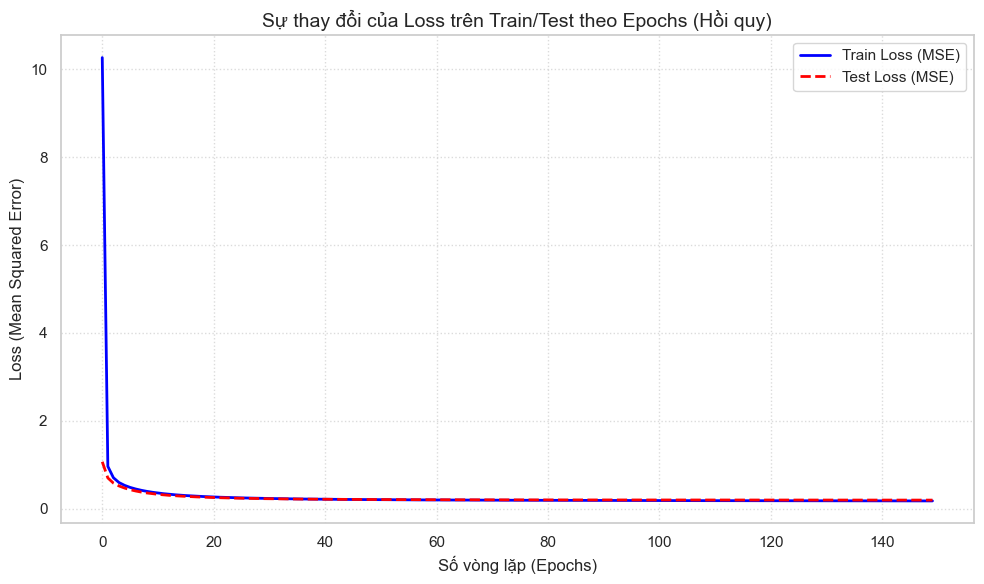

In [17]:
import matplotlib.pyplot as plt

# Sử dụng MLPRegressor với warm_start=True để mô phỏng quá trình học qua từng epoch
mlp_plot = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1, warm_start=True, random_state=42, solver='sgd', learning_rate_init=0.01)

epochs = 150
train_losses, test_losses = [], []

print("Đang huấn luyện và ghi nhận Loss theo từng Epoch...")
for epoch in range(epochs):
    mlp_plot.fit(X_train, y_train) # Vì warm_start=True nên nó sẽ học tiếp tục
    
    # Hàm loss mặc định của MLPRegressor là MSE
    train_losses.append(mlp_plot.loss_) 
    
    # Tính Loss trên tập Test
    y_test_pred = mlp_plot.predict(X_test)
    test_losses.append(mean_squared_error(y_test, y_test_pred) / 2) # Chia 2 để cùng thang đo với hàm loss của MLP

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss (MSE)', color='blue', linewidth=2)
plt.plot(test_losses, label='Test Loss (MSE)', color='red', linestyle='--', linewidth=2)
plt.title('Sự thay đổi của Loss trên Train/Test theo Epochs (Hồi quy)', fontsize=14)
plt.xlabel('Số vòng lặp (Epochs)')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()